# VQA LLMs Competition - Results Analysis

This notebook analyzes the predictions of various Vision-Language Models (VLMs) on the VQA competition dataset. 
It uses semantic similarity based on sentence embeddings to evaluate LLM responses against ground truth answers. 

The evaluation compares two matching strategies:
1. **Exact Match (EM)**: Case-insensitive exact string match after basic normalization.
2. **Semantic Match (SM)**: Cosine similarity threshold match based on embeddings from the `all-MiniLM-L6-v2` model (handles synonyms, typos, spelling variations, etc.).

We evaluate four specific results files: two runs of older configurations ("not updated") and two runs of newer configurations ("updated") to measure the performance improvements.

In [1]:
# Cell 1: Install dependencies and import libraries
import sys
import subprocess

try:
    import sentence_transformers
except ImportError:
    print("Installing sentence-transformers (this might take a few seconds)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sentence-transformers"])
    import sentence_transformers

import os
import re
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer, util

print("\n✅ Imports successful!")
print(f"sentence-transformers version: {sentence_transformers.__version__}")


✅ Imports successful!
sentence-transformers version: 5.6.0


## Configuration: Target Input Files

We define the 4 specific results files (2 updated, 2 not updated) as specified in the configuration.

In [2]:
# Cell 2: File initialization configuration
RESULTS_DIR = Path("LLMsResults")

# 2 of notUpdated by LLM question runs
NOT_UPDATED_FILES = {
    "qwen2.5-vl-7b-instruct (not updated)": RESULTS_DIR / "qwen2.5-vl-7b-instruct_results_20260613_201034.csv",
    "gemma-4-e4b-it-mlx (not updated)": RESULTS_DIR / "gemma-4-e4b-it-mlx_results_20260607_141849.csv"
}

# 2 of UpdatedByLLM question runs
UPDATED_FILES = {
    "qwen2.5-vl-7b-instruct (updated)": RESULTS_DIR / "qwen2.5-vl-7b-instruct_results_20260614_202918.csv",
    "gemma-4-e4b-it-mlx (updated)": RESULTS_DIR / "gemma-4-e4b-it-mlx_results_20260614_140518.csv"
}

# Combine all target files for unified iteration
TARGET_FILES = {**NOT_UPDATED_FILES, **UPDATED_FILES}

print("Initialized target files for evaluation:")
for name, path in TARGET_FILES.items():
    status = "✅ Found" if path.exists() else "❌ Missing"
    print(f" - {name:<40}: {path} ({status})")

Initialized target files for evaluation:
 - qwen2.5-vl-7b-instruct (not updated)    : LLMsResults/qwen2.5-vl-7b-instruct_results_20260613_201034.csv (✅ Found)
 - gemma-4-e4b-it-mlx (not updated)        : LLMsResults/gemma-4-e4b-it-mlx_results_20260607_141849.csv (✅ Found)
 - qwen2.5-vl-7b-instruct (updated)        : LLMsResults/qwen2.5-vl-7b-instruct_results_20260614_202918.csv (✅ Found)
 - gemma-4-e4b-it-mlx (updated)            : LLMsResults/gemma-4-e4b-it-mlx_results_20260614_140518.csv (✅ Found)


## Semantic Word Matcher

We create a `SemanticMatcher` utility class that handles text normalization (e.g. converting underscores to spaces, lowercasing) and computes cosine similarity of sentence-transformer embeddings with cache optimization.

In [3]:
# Cell 3: SemanticMatcher utility class

class SemanticMatcher:
    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        print(f"Loading SentenceTransformer model: {model_name}...")
        # Loads model (or uses cached version under ~/.cache/huggingface/hub)
        self.model = SentenceTransformer(model_name)
        self.embedding_cache = {}
        print("✅ Model loaded successfully!")
        
    def _normalize_text(self, text: str) -> str:
        if not isinstance(text, str):
            text = str(text) if text is not None else ""
        # Replace underscores with spaces (e.g., chopping_board -> chopping board)
        text = text.replace('_', ' ')
        # Standardize whitespace and lowercase
        text = re.sub(r'\s+', ' ', text).strip().lower()
        
        # Standardize regional synonyms and fix ground truth typos
        mappings = {
            "beaf": "beef",
            "capsicum": "bell pepper"
        }
        if text in mappings:
            text = mappings[text]
            
        return text

    def get_embedding(self, text: str):
        normalized = self._normalize_text(text)
        if normalized not in self.embedding_cache:
            self.embedding_cache[normalized] = self.model.encode(normalized, convert_to_tensor=True)
        return self.embedding_cache[normalized]

    def similarity(self, word_a: str, word_b: str) -> float:
        norm_a = self._normalize_text(word_a)
        norm_b = self._normalize_text(word_b)
        if norm_a == norm_b:
            return 1.0
        if not norm_a or not norm_b:
            return 0.0
            
        emb_a = self.get_embedding(norm_a)
        emb_b = self.get_embedding(norm_b)
        
        # Calculate cosine similarity
        sim_tensor = util.cos_sim(emb_a, emb_b)
        return float(sim_tensor.item())

    def is_match(self, word_a: str, word_b: str, threshold: float = 0.7) -> bool:
        return self.similarity(word_a, word_b) >= threshold

# Initialize global matcher instance
matcher = SemanticMatcher()

Loading SentenceTransformer model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Model loaded successfully!


## Interactive Demo

Let's test the similarity scores on domain-specific word pairs to see if spelling variations, synonyms, typos, and common names are successfully recognized.

In [4]:
# Cell 4: Demo of similarity scores for domain-specific pairs

demo_pairs = [
    ("yoghurt", "yogurt"),
    ("chilli", "chili"),
    ("kiwifruit", "kiwi"),
    ("chopping_board", "cutting board"),
    ("capsicum", "bell pepper"),
    ("beaf", "beef"),
    ("green_apple", "apple"),
    ("green_apple", "green apple"),
    ("bread", "baguette"),
    ("pear", "apple"),      # Negative case
    ("chicken", "beef"),    # Negative case
]

print("--- Testing Semantic Word Similarity ---")
print(f"{'Word Pair':<45} | {'Cosine Sim':<12} | {'Is Match (>=0.7)':<15}")
print("-" * 80)
for word_a, word_b in demo_pairs:
    sim = matcher.similarity(word_a, word_b)
    is_match = matcher.is_match(word_a, word_b, threshold=0.7)
    pair_str = f"'{word_a}' <-> '{word_b}'"
    print(f"{pair_str:<45} | {sim:.4f}       | {is_match}")

--- Testing Semantic Word Similarity ---
Word Pair                                     | Cosine Sim   | Is Match (>=0.7)
--------------------------------------------------------------------------------
'yoghurt' <-> 'yogurt'                        | 0.8407       | True


'chilli' <-> 'chili'                          | 0.7650       | True
'kiwifruit' <-> 'kiwi'                        | 0.8383       | True
'chopping_board' <-> 'cutting board'          | 0.7588       | True
'capsicum' <-> 'bell pepper'                  | 1.0000       | True
'beaf' <-> 'beef'                             | 1.0000       | True
'green_apple' <-> 'apple'                     | 0.6693       | False
'green_apple' <-> 'green apple'               | 1.0000       | True
'bread' <-> 'baguette'                        | 0.5247       | False
'pear' <-> 'apple'                            | 0.4744       | False
'chicken' <-> 'beef'                          | 0.6052       | False


## Load & Parse VQA LLM Results

We load the target files defined in the configuration section, parse the JSON fields, and clean up the answer lists.

In [5]:
# Cell 5: Load and parse target results files

# Helper function to parse JSON response from LLM
def parse_json_response(response_str: str) -> dict | None:
    if not response_str or not isinstance(response_str, str):
        return None

    # Try extracting markdown json block
    match = re.search(r'```(?:json)?\s*([\s\S]*?)\s*```', response_str)
    if match:
        json_str = match.group(1).strip()
    else: 
        # Fallback to finding outermost curly braces
        brace_match = re.search(r'\{[\s\S]*\}', response_str)
        json_str = brace_match.group(0).strip() if brace_match else response_str.strip()

    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        try:
            # Fallback to unescape double quotes if present
            cleaned = json_str.replace('""', '"')
            return json.loads(cleaned)
        except:
            return None

# Extract answer list from the parsed json
def extract_answers(response_str: str) -> list[str]:
    parsed = parse_json_response(response_str)
    if not parsed or not isinstance(parsed, dict):
        return []
    
    ans = parsed.get("answer", [])
    if isinstance(ans, list):
        return [str(a) for a in ans if a is not None]
    elif isinstance(ans, str):
        return [ans]
    return []

# Load target files
dfs = {}
for model_name, csv_path in TARGET_FILES.items():
    if not csv_path.exists():
        print(f"⚠️ Warning: CSV file not found at {csv_path}")
        continue
    df = pd.read_csv(csv_path)
    
    # Parse LLM response and extract predictions list
    df["predicted_answers"] = df["llm_response"].apply(extract_answers)
    dfs[model_name] = df
    print(f"✅ Loaded {len(df)} rows for {model_name} from: {csv_path.name}")

✅ Loaded 1000 rows for qwen2.5-vl-7b-instruct (not updated) from: qwen2.5-vl-7b-instruct_results_20260613_201034.csv
✅ Loaded 1000 rows for gemma-4-e4b-it-mlx (not updated) from: gemma-4-e4b-it-mlx_results_20260607_141849.csv


✅ Loaded 1000 rows for qwen2.5-vl-7b-instruct (updated) from: qwen2.5-vl-7b-instruct_results_20260614_202918.csv
✅ Loaded 1000 rows for gemma-4-e4b-it-mlx (updated) from: gemma-4-e4b-it-mlx_results_20260614_140518.csv


## Compute Exact and Semantic Accuracy

For each row, we compare each element in the LLM's predicted answers against the ground truth:
- We check for an **exact match** (case-insensitive, basic whitespace normalization).
- We compute the **cosine similarity** between the ground truth and each predicted answer, and take the **maximum similarity**.
- We classify it as a **semantic match** if the maximum similarity is above a threshold. We run a sensitivity analysis with thresholds `0.6`, `0.7`, and `0.8`.

In [6]:
# Cell 6: Compute match scores per row and perform sensitivity analysis

thresholds = [0.6, 0.7, 0.8]
analysis_results = {}

for model_name, df in dfs.items():
    print(f"\nProcessing results for {model_name}...")
    
    exact_matches = []
    max_similarities = []
    best_matching_answers = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=model_name):
        gt = row["ground_truth"]
        predictions = row["predicted_answers"]
        
        if not predictions:
            exact_matches.append(False)
            max_similarities.append(0.0)
            best_matching_answers.append(None)
            continue
            
        gt_norm = matcher._normalize_text(gt)
        row_exact = False
        row_max_sim = 0.0
        best_ans = predictions[0]
        
        for pred in predictions:
            pred_norm = matcher._normalize_text(pred)
            if pred_norm == gt_norm:
                row_exact = True
            
            sim = matcher.similarity(gt, pred)
            if sim > row_max_sim:
                row_max_sim = sim
                best_ans = pred
                
        exact_matches.append(row_exact)
        max_similarities.append(row_max_sim)
        best_matching_answers.append(best_ans)
        
    df["exact_match"] = exact_matches
    df["max_similarity"] = max_similarities
    df["best_matching_answer"] = best_matching_answers
    
    # Add semantic match flags
    for t in thresholds:
        df[f"semantic_match_{t}"] = df["max_similarity"] >= t
        
    # Aggregate metrics
    total_rows = len(df)
    em_acc = df["exact_match"].mean() * 100
    
    analysis_results[model_name] = {
        "total": total_rows,
        "exact_match_accuracy": em_acc,
    }
    
    print(f"🤖 {model_name} - Exact Match Accuracy: {em_acc:.2f}%")
    for t in thresholds:
        sm_acc = df[f"semantic_match_{t}"].mean() * 100
        analysis_results[model_name][f"semantic_match_{t}_accuracy"] = sm_acc
        print(f"   └─ Semantic Match (threshold={t}): {sm_acc:.2f}%")


Processing results for qwen2.5-vl-7b-instruct (not updated)...


qwen2.5-vl-7b-instruct (not updated):   0%|          | 0/1000 [00:00<?, ?it/s]

🤖 qwen2.5-vl-7b-instruct (not updated) - Exact Match Accuracy: 48.30%
   └─ Semantic Match (threshold=0.6): 61.50%
   └─ Semantic Match (threshold=0.7): 58.40%
   └─ Semantic Match (threshold=0.8): 53.20%

Processing results for gemma-4-e4b-it-mlx (not updated)...


gemma-4-e4b-it-mlx (not updated):   0%|          | 0/1000 [00:00<?, ?it/s]

🤖 gemma-4-e4b-it-mlx (not updated) - Exact Match Accuracy: 22.00%
   └─ Semantic Match (threshold=0.6): 34.40%
   └─ Semantic Match (threshold=0.7): 30.20%
   └─ Semantic Match (threshold=0.8): 25.60%

Processing results for qwen2.5-vl-7b-instruct (updated)...


qwen2.5-vl-7b-instruct (updated):   0%|          | 0/1000 [00:00<?, ?it/s]

🤖 qwen2.5-vl-7b-instruct (updated) - Exact Match Accuracy: 43.10%
   └─ Semantic Match (threshold=0.6): 52.50%
   └─ Semantic Match (threshold=0.7): 49.70%
   └─ Semantic Match (threshold=0.8): 47.00%

Processing results for gemma-4-e4b-it-mlx (updated)...


gemma-4-e4b-it-mlx (updated):   0%|          | 0/1000 [00:00<?, ?it/s]

🤖 gemma-4-e4b-it-mlx (updated) - Exact Match Accuracy: 23.90%
   └─ Semantic Match (threshold=0.6): 35.10%
   └─ Semantic Match (threshold=0.7): 31.20%
   └─ Semantic Match (threshold=0.8): 27.90%


## Results Summary, Comparison & Worst Cases

We present a comparison of the results across all thresholds (`0.6`, `0.7`, and `0.8`), evaluate the differences between the original runs (Not Updated) and the newer prompt runs (Updated), and document the worst-case failures where similarity was lowest, along with the source question and image.

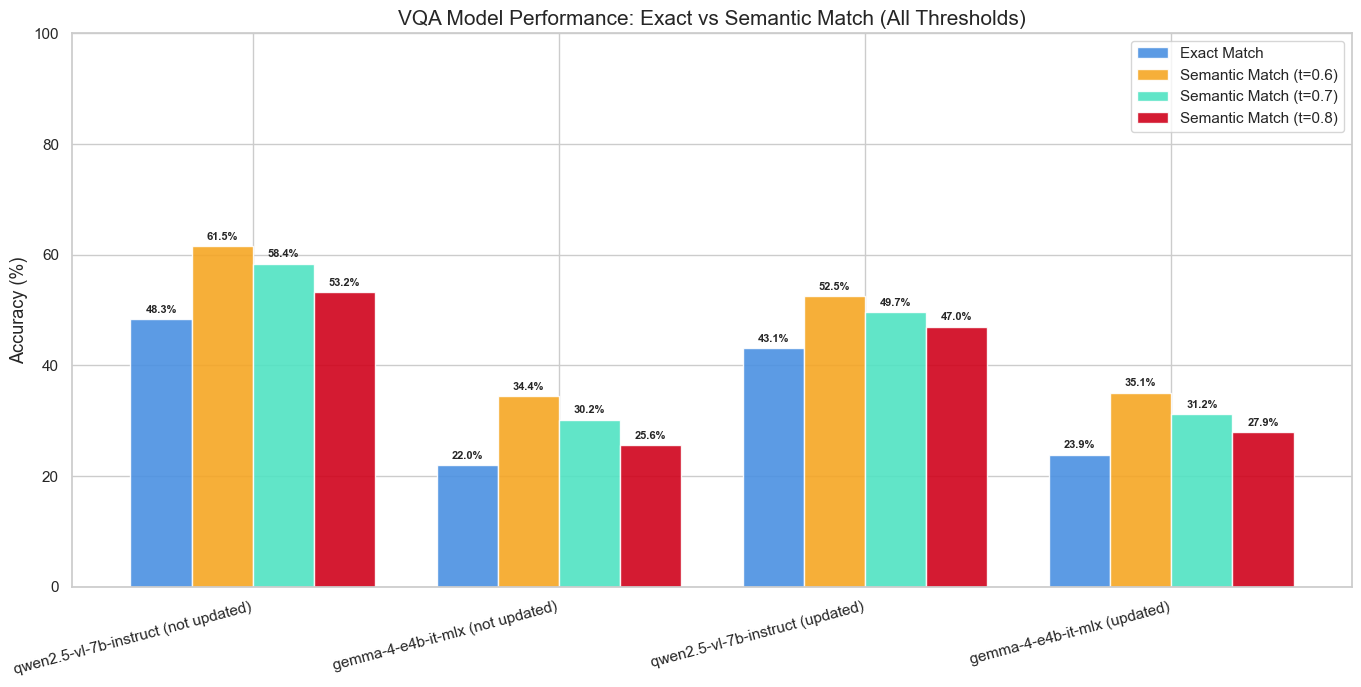


📊 Performance Comparison: NotUpdated vs. Updated Configurations
Model Family              | Metric                    | Not Updated  | Updated      | Difference
-----------------------------------------------------------------------------------------------
Qwen2.5-VL-7B-Instruct    | Exact Match               | 48.30%     | 43.10%     | -5.20%
                          | Semantic Match (t=0.6)    | 61.50%     | 52.50%     | -9.00%
                          | Semantic Match (t=0.7)    | 58.40%     | 49.70%     | -8.70%
                          | Semantic Match (t=0.8)    | 53.20%     | 47.00%     | -6.20%
-----------------------------------------------------------------------------------------------
Gemma-4-E4B-IT-MLX        | Exact Match               | 22.00%     | 23.90%     | +1.90%
                          | Semantic Match (t=0.6)    | 34.40%     | 35.10%     | +0.70%
                          | Semantic Match (t=0.7)    | 30.20%     | 31.20%     | +1.00%
                       

In [7]:
# Cell 7: Visualizations and analysis report

# Clean plot settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 17
})

# 1. Plot overall performance comparison across all thresholds
models = list(analysis_results.keys())
em_scores = [analysis_results[m]["exact_match_accuracy"] for m in models]
sm6_scores = [analysis_results[m]["semantic_match_0.6_accuracy"] for m in models]
sm7_scores = [analysis_results[m]["semantic_match_0.7_accuracy"] for m in models]
sm8_scores = [analysis_results[m]["semantic_match_0.8_accuracy"] for m in models]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - 1.5*width, em_scores, width, label='Exact Match', color='#4A90E2', alpha=0.9)
rects2 = ax.bar(x - 0.5*width, sm6_scores, width, label='Semantic Match (t=0.6)', color='#F5A623', alpha=0.9)
rects3 = ax.bar(x + 0.5*width, sm7_scores, width, label='Semantic Match (t=0.7)', color='#50E3C2', alpha=0.9)
rects4 = ax.bar(x + 1.5*width, sm8_scores, width, label='Semantic Match (t=0.8)', color='#D0021B', alpha=0.9)

ax.set_ylabel('Accuracy (%)')
ax.set_title('VQA Model Performance: Exact vs Semantic Match (All Thresholds)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0, 100)
ax.legend()

# Add values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, weight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
fig.tight_layout()
plt.show()

# 2. Compare NotUpdated and Updated data directly
print("\n=========================================================================")
print("📊 Performance Comparison: NotUpdated vs. Updated Configurations")
print("=========================================================================")

qwen_not = "qwen2.5-vl-7b-instruct (not updated)"
qwen_upd = "qwen2.5-vl-7b-instruct (updated)"
gemma_not = "gemma-4-e4b-it-mlx (not updated)"
gemma_upd = "gemma-4-e4b-it-mlx (updated)"

comparisons = [
    ("Qwen2.5-VL-7B-Instruct", qwen_not, qwen_upd),
    ("Gemma-4-E4B-IT-MLX", gemma_not, gemma_upd)
]

print(f"{'Model Family':<25} | {'Metric':<25} | {'Not Updated':<12} | {'Updated':<12} | {'Difference':<10}")
print("-" * 95)
for family, key_not, key_upd in comparisons:
    if key_not in analysis_results and key_upd in analysis_results:
        # EM Comparison
        em_not = analysis_results[key_not]["exact_match_accuracy"]
        em_upd = analysis_results[key_upd]["exact_match_accuracy"]
        em_diff = em_upd - em_not
        print(f"{family:<25} | {'Exact Match':<25} | {em_not:.2f}%     | {em_upd:.2f}%     | {em_diff:+.2f}%")
        
        # SM Comparisons
        for t in [0.6, 0.7, 0.8]:
            sm_not = analysis_results[key_not][f"semantic_match_{t}_accuracy"]
            sm_upd = analysis_results[key_upd][f"semantic_match_{t}_accuracy"]
            sm_diff = sm_upd - sm_not
            print(f"{'':<25} | {f'Semantic Match (t={t})':<25} | {sm_not:.2f}%     | {sm_upd:.2f}%     | {sm_diff:+.2f}%")
        print("-" * 95)

# 3. Print worst-case scenarios (including question and image path)
print("\n=========================================================================")
print("⚠️ Worst-Case Scenarios: Lowest Similarity Scores (Complete Misses)")
print("=========================================================================")

for model_name, df in dfs.items():
    # Filter rows that have predictions but similarity is low
    wrong_preds = df[df["predicted_answers"].apply(len) > 0]
    wrong_preds = wrong_preds.sort_values(by="max_similarity", ascending=True)
    
    if not wrong_preds.empty:
        print(f"\n🤖 Model: {model_name} (Showing top 5 worst predictions)")
        print("-" * 115)
        for i, (_, row) in enumerate(wrong_preds.head(5).iterrows(), 1):
            gt = row["ground_truth"]
            preds = str(row["predicted_answers"])
            best = row["best_matching_answer"]
            sim = row["max_similarity"]
            q = row["question"]
            img = row["image_path"]
            
            print(f" {i}. Ground Truth: '{gt}' | Predictions: {preds} | Best Match: '{best}' (Cosine Sim: {sim:.4f})")
            print(f"    🖼️  Image Path: {img}")
            print(f"    ❓ Question:   \"{q}\"")
            print("-" * 115)

## Save Fidelity Assessment Reports

We create a dedicated function to save copies of the evaluated datasets inside a folder named `Fidelity_Assessment`. Each file has the suffix `_Fidelity_Assessment.csv` and contains all original data columns plus the evaluation results: `ExactAccuracy` (boolean/int), `thresholdAccuracy` (float cosine similarity score), and `verdict` (boolean representing correctness at the recommended 0.7 threshold).

In [8]:
# Cell 8: Save Fidelity Assessment reports

def save_fidelity_assessment(dfs, target_files, output_dir_name="Fidelity_Assessment"):
    # Output directory relative to current directory (VQA_LLMs_competition)
    output_dir = Path(output_dir_name)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Saving Fidelity Assessment reports to folder: {output_dir.resolve()}\n")
    
    for key, df in dfs.items():
        # Get the original filename
        csv_path = target_files[key]
        original_stem = csv_path.stem  # e.g. qwen2.5-vl-7b-instruct_results_20260613_201034
        
        # New filename: original_name_Fidelity_Assessment.csv
        new_filename = f"{original_stem}_Fidelity_Assessment.csv"
        new_path = output_dir / new_filename
        
        # Create a copy of the dataframe
        assessment_df = df.copy()
        
        # Add requested columns
        assessment_df["ExactAccuracy"] = assessment_df["exact_match"]
        
        # Store the float similarity score
        assessment_df["thresholdAccuracy"] = assessment_df.apply(
            lambda r: float(round(r["max_similarity"], 4)), axis=1
        )
        
        # verdict represents if the prediction was semantically correct at recommended threshold 0.7
        assessment_df["verdict"] = assessment_df["semantic_match_0.7"]
        
        # Keep original columns and append the new assessment columns
        original_cols = ["index", "image_path", "question", "complexity", "ground_truth", "llm_response", "timestamp"]
        new_cols = ["ExactAccuracy", "thresholdAccuracy", "verdict"]
        
        # Select only these columns for output
        final_df = assessment_df[original_cols + new_cols]
        
        # Save to CSV
        final_df.to_csv(new_path, index=False)
        print(f" 💾 Saved assessment report: {new_filename} ({len(final_df)} rows)")

# Execute export function
save_fidelity_assessment(dfs, TARGET_FILES)

Saving Fidelity Assessment reports to folder: /Users/macuser/GitHub/LoRA-project/VQA_LLMs_competition/Fidelity_Assessment

 💾 Saved assessment report: qwen2.5-vl-7b-instruct_results_20260613_201034_Fidelity_Assessment.csv (1000 rows)
 💾 Saved assessment report: gemma-4-e4b-it-mlx_results_20260607_141849_Fidelity_Assessment.csv (1000 rows)
 💾 Saved assessment report: qwen2.5-vl-7b-instruct_results_20260614_202918_Fidelity_Assessment.csv (1000 rows)
 💾 Saved assessment report: gemma-4-e4b-it-mlx_results_20260614_140518_Fidelity_Assessment.csv (1000 rows)
